<b>Workforce Planning</b>

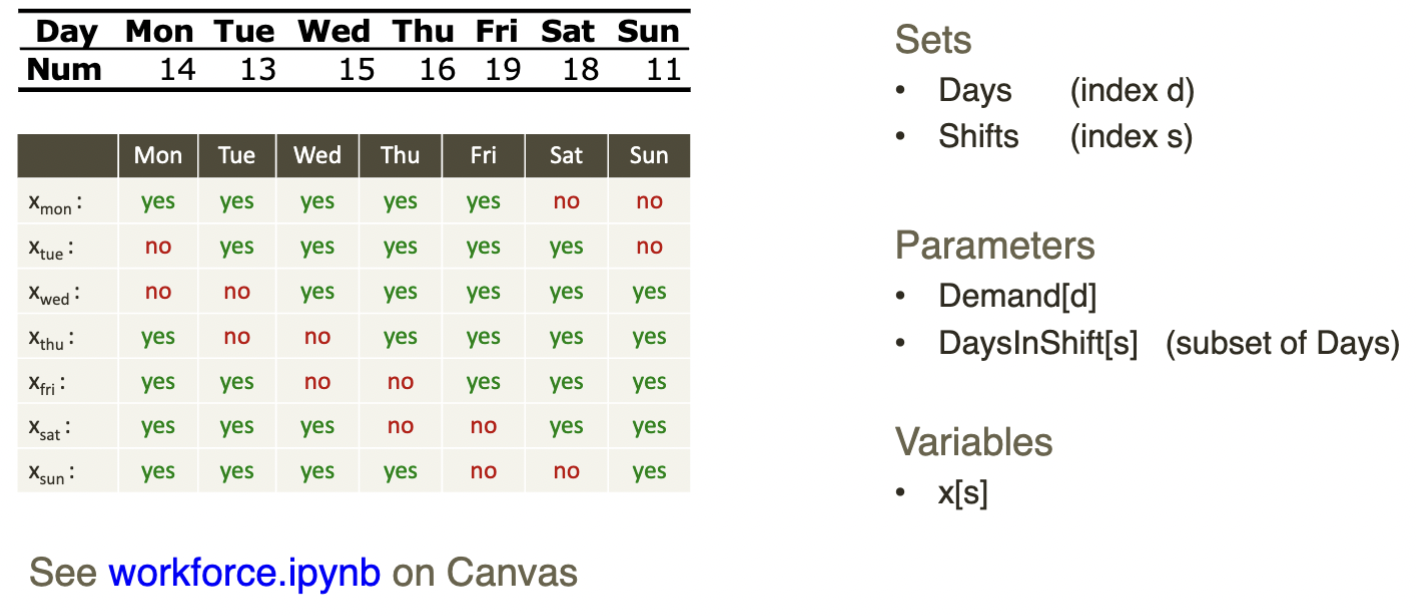

In [1]:
# Input data
Days = {'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'}
Shifts = {'StartMon', 'StartTue', 'StartWed', 'StartThu', 'StartFri', 'StartSat', 'StartSun'}
DaysInShift = {
    'StartMon' : {'Mon', 'Tue', 'Wed', 'Thu', 'Fri'},
    'StartTue' : {'Tue', 'Wed', 'Thu', 'Fri', 'Sat'},
    'StartWed' : {'Wed', 'Thu', 'Fri', 'Sat', 'Sun'},
    'StartThu' : {'Mon', 'Thu', 'Fri', 'Sat', 'Sun'},
    'StartFri' : {'Mon', 'Tue', 'Fri', 'Sat', 'Sun'},
    'StartSat' : {'Mon', 'Tue', 'Wed', 'Sat', 'Sun'},
    'StartSun' : {'Mon', 'Tue', 'Wed', 'Thu', 'Sun'} 
}
Demand = {'Mon' : 14, 'Tue' : 13, 'Wed' : 15, 'Thu' : 16, 'Fri' : 19, 'Sat' : 18, 'Sun' : 11}

In [2]:
from docplex.mp.model import Model
mdl = Model()

In [3]:
# variables
Workers = mdl.continuous_var_dict(Shifts, lb=0, name=Shifts)

In [4]:
# objective
mdl.minimize(mdl.sum(Workers[s] for s in Shifts))

In [5]:
# demand constraints for each day
for d in Days:
    mdl.add(mdl.sum(Workers[s] for s in Shifts if d in DaysInShift[s]) >= Demand[d])

In [6]:
# solve
mdl.solve()
mdl.get_solve_details()

docplex.mp.SolveDetails(time=0,status='optimal')

In [7]:
mdl.print_solution()

objective: 22.000
  StartSat=3.000
  StartMon=4.000
  StartFri=3.000
  StartWed=5.000
  StartThu=4.000
  StartTue=3.000
